In [1]:
!pip install pandas numpy matplotlib scipy scikit-learn jupyter ipykernel openpyxl statsmodels yellowbrick

In [2]:
# Data Manipulation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Statistics
from scipy import stats
from scipy.stats import ttest_ind, chi2_contingency

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Evaluation Metrics
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

%matplotlib inline

In [3]:
# Load dataset
df = pd.read_csv(r"C:\Users\karth\apexplanet-data-analytics\data\Sample - Superstore.csv",encoding="cp1252")

# Basic operations
print(df.shape)

df.head()

df.info()

df.describe(include="all")

df.isnull().sum()

df.duplicated().sum()

(9994, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 1

np.int64(0)

In [4]:
# Data Cleaning
# Remove duplicates
df.drop_duplicates(inplace=True)

# Convert dates
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

# Check datatypes
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

In [5]:
# Descriptive operations
numerical = [
    "Sales",
    "Profit",
    "Quantity",
    "Discount"
]

summary = pd.DataFrame({
    "Mean":df[numerical].mean(),
    "Median":df[numerical].median(),
    "Standard Deviation":df[numerical].std(),
    "Variance":df[numerical].var(),
    "Skewness":df[numerical].skew(),
    "Minimum":df[numerical].min(),
    "Maximum":df[numerical].max()
})

summary

,Mean,Median,Standard Deviation,Variance,Skewness,Minimum,Maximum
Sales,229.858001,54.4900,623.245101,388434.455308,12.972752,0.444,22638.480
Profit,28.656896,8.6665,234.260108,54877.798055,7.561432,-6599.978,8399.976
Quantity,3.789574,3.0000,2.225110,4.951113,1.278545,1.000,14.000
Discount,0.156203,0.2000,0.206452,0.042622,1.684295,0.000,0.800


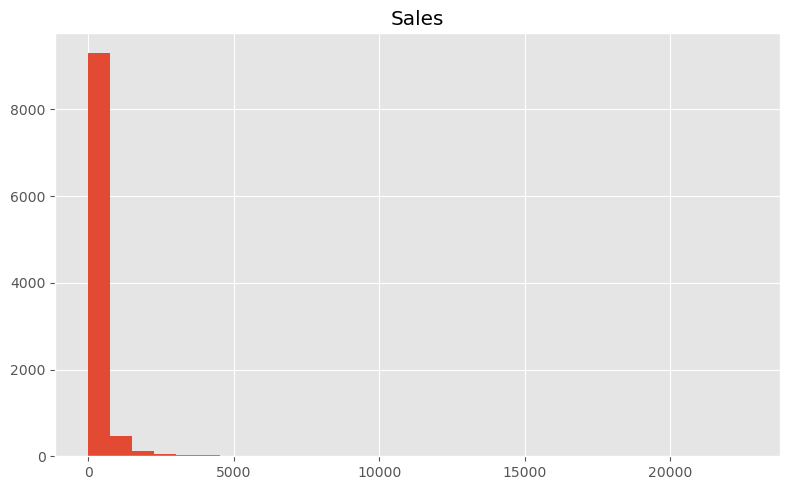

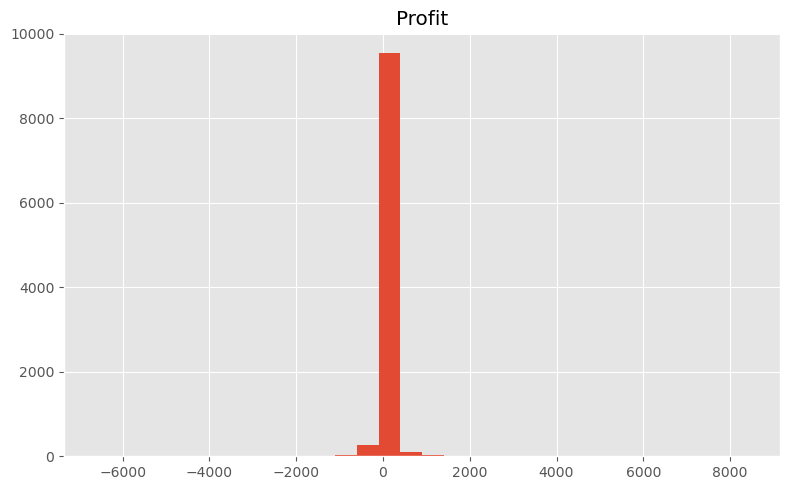

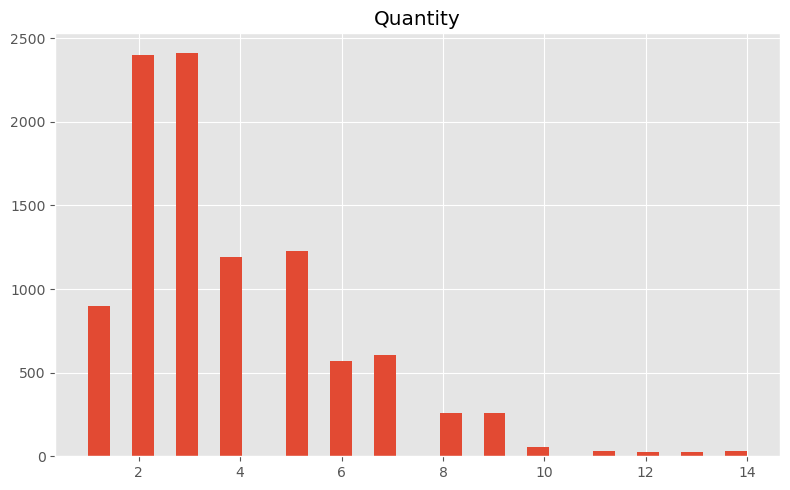

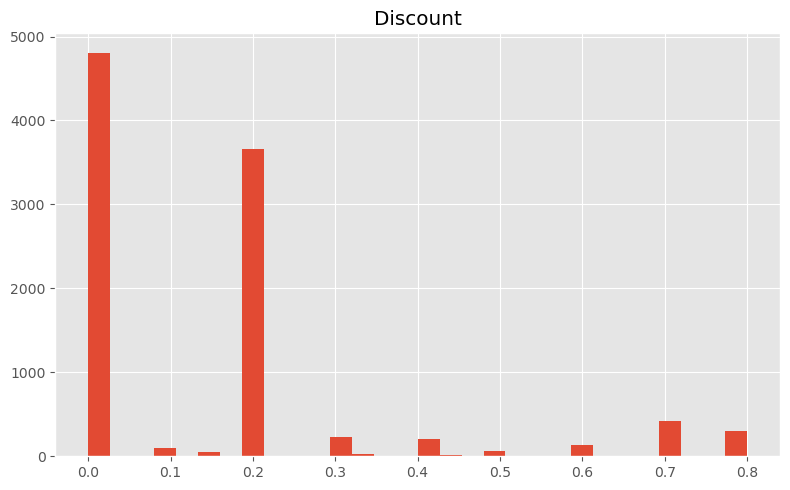

In [6]:
# Distribution Plots
for column in numerical:
    plt.figure(figsize=(8,5))
    plt.hist(df[column],bins=30)
    plt.title(column)
    plt.tight_layout()
    plt.savefig("Distribution_plots.png", dpi=300)
    plt.show()

In [7]:
# Statistical Testing
# T test
office = df[df["Category"]=="Office Supplies"]["Sales"]
technology = df[df["Category"]=="Technology"]["Sales"]
t,p = ttest_ind(office,technology)

print("T Statistic :",t)
print("P Value :",p)

# Chi Square Test
table = pd.crosstab(
    df["Region"],
    df["Ship Mode"]
)

chi,p,dof,expected = chi2_contingency(table)

print("\nChi Square:",chi)
print("P Value:",p)

T Statistic : -19.817734170475198
P Value : 2.459502339530819e-85

Chi Square: 23.846239703707703
P Value: 0.004551137492452852


In [8]:
# Confidence Interval
mean = df["Sales"].mean()

std = df["Sales"].std()

n = len(df)

margin = stats.t.ppf(
    0.975,
    n-1
)*(std/np.sqrt(n))

lower = mean-margin

upper = mean+margin

print("Lower :",lower)
print("Upper :",upper)

Lower : 217.6374748989753
Upper : 242.07852676202123


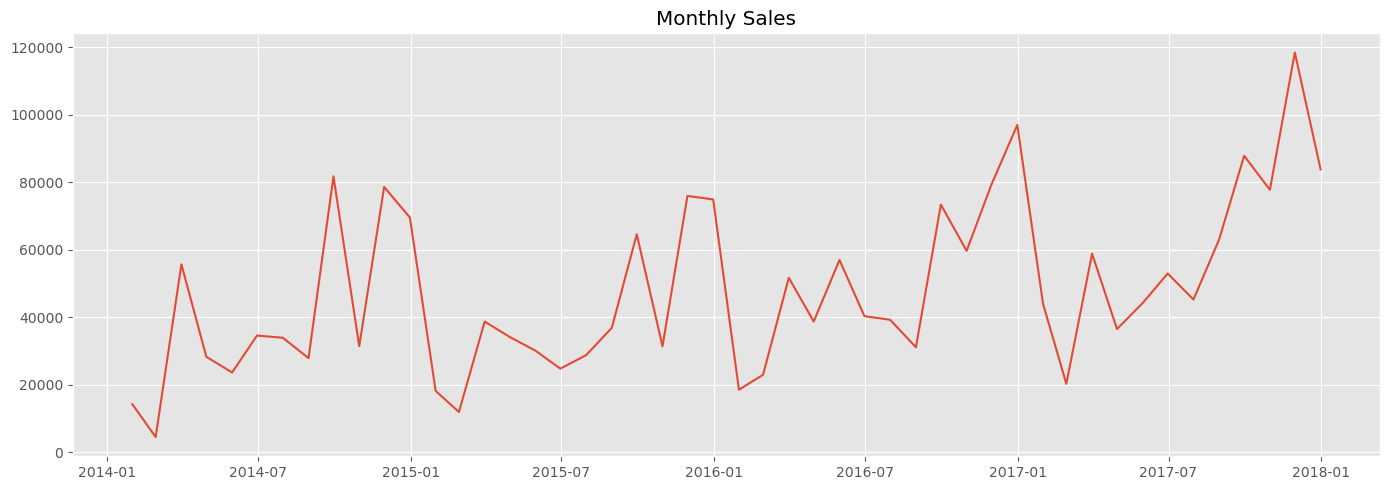

In [9]:
# Time series Analysis
monthly_sales = (
    df.set_index("Order Date").resample("M")["Sales"].sum()
)

# Plot Monthly Sales average
plt.figure(figsize=(14,5))
plt.plot(monthly_sales)
plt.title("Monthly Sales")
plt.tight_layout()
plt.savefig("Mpnthly_Sales.png", dpi=300)
plt.show()

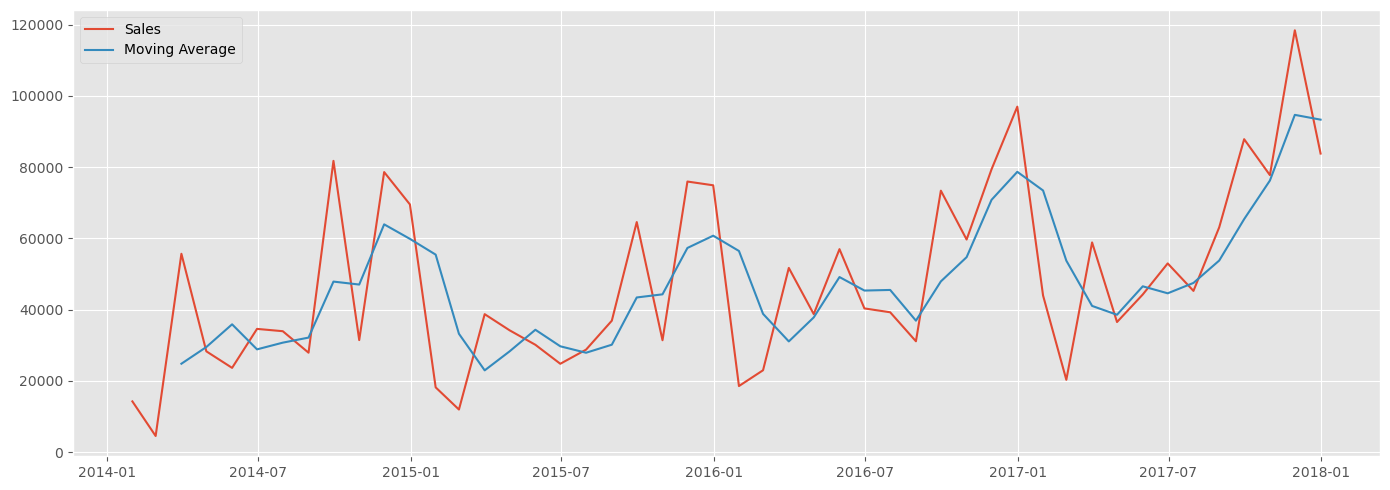

In [10]:
# Moving Average
moving = monthly_sales.rolling(3).mean()

plt.figure(figsize=(14,5))
plt.plot(monthly_sales,label="Sales")
plt.plot(moving,label="Moving Average")
plt.legend()
plt.tight_layout()
plt.savefig("Moving_Average.png", dpi=300)
plt.show()

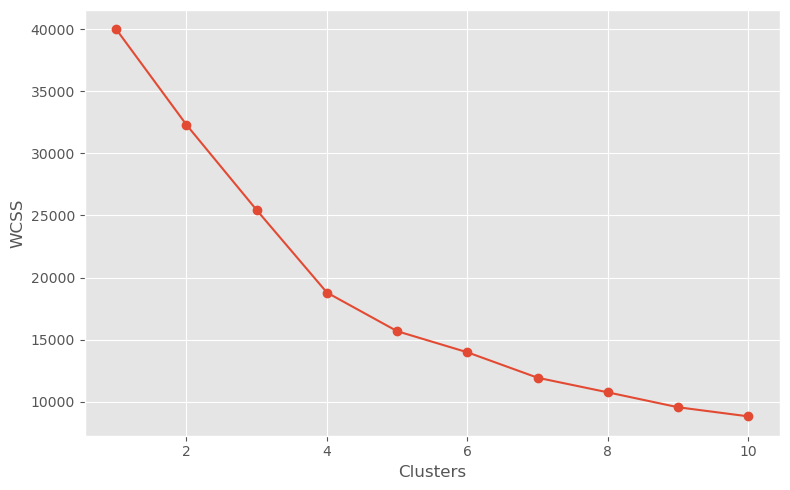

In [11]:
# Customer Segmentation

X = df[["Sales","Profit","Quantity","Discount"]]
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Elbow Method
wcss=[]

for i in range(1,11):

    model=KMeans(n_clusters=i,random_state=42,n_init=10)
    model.fit(X_scaled)
    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11),wcss,marker="o")

plt.xlabel("Clusters")

plt.ylabel("WCSS")
plt.tight_layout()
plt.savefig("Clusters.png", dpi=300)

plt.show()

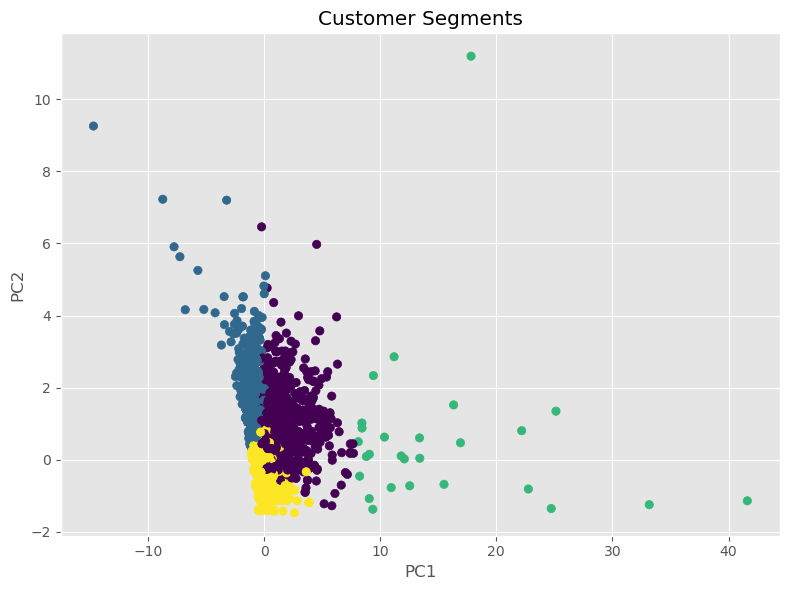

,Sales,Profit,Quantity,Discount
Cluster,,,,
0,407.908020,69.790464,6.452784,0.094655
1,153.637349,-108.306796,3.836207,0.667960
2,7685.179259,2610.220085,5.185185,0.070370
3,126.813585,21.516522,2.533279,0.097487


In [12]:
# KMeans as cluster
kmeans=KMeans(n_clusters=4,random_state=42,n_init=10)
df["Cluster"]=kmeans.fit_predict(X_scaled)

# PCA as points
pca=PCA(n_components=2)
points=pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(points[:,0],points[:,1],c=df["Cluster"])

plt.xlabel("PC1")

plt.ylabel("PC2")

plt.title("Customer Segments")
plt.tight_layout()
plt.savefig("Customer_Segments.png", dpi=300)

plt.show()

# Cluster Summary
df.groupby("Cluster")[["Sales","Profit","Quantity","Discount"]].mean()

In [13]:
# Predictive Analysis

X=df[
[
"Sales",
"Quantity",
"Discount"
]
]

y=df["Profit"]

# Train Test
X_train,X_test,y_train,y_test=train_test_split(

X,
y,

test_size=0.2,

random_state=42
)

# Train Model
model=LinearRegression()

model.fit(
X_train,
y_train
)

# Prediction
prediction=model.predict(X_test)

# Evaluation
print("Mean Absolute Error :",mean_absolute_error(y_test,prediction))

print("Mean Squared Error :",mean_squared_error(y_test,prediction))

print("RMean Squared Error :",np.sqrt(mean_squared_error(y_test,prediction)))

print("R2 Score :",r2_score(y_test,prediction))

Mean Absolute Error : 69.77214730362897
Mean Squared Error : 83592.67395643327
RMean Squared Error : 289.12397679271305
R2 Score : -0.7240890405096132


In [14]:
# Feature Inportance

importance=pd.DataFrame({
"Feature":X.columns,
"Coefficient":model.coef_
})

importance.sort_values(
"Coefficient",
ascending=False
)

,Feature,Coefficient
0,Sales,0.259335
1,Quantity,-6.512035
2,Discount,-208.858709


Conclusions

1. Technology products generate the highest average sales.
2. High discounts are associated with lower profits.
3. Monthly sales exhibit an increasing trend with seasonal fluctuations.
4. K-Means identified four distinct customer segments.
5. One cluster contains high-value customers with high sales and profit.
6. The regression model indicates that Sales positively influence Profit, while Discount has a negative impact.